## LDA y Máquinas de Soporte Vectorial (SVM)

### Representación, clasificación, validación y selección de modelos

Esta notebook integra dos técnicas de clasificación supervisada estudiadas en la teoría: **Análisis Discriminante Lineal (LDA)** y **Máquinas de Soporte Vectorial (SVM)**. El objetivo no es solamente entrenar clasificadores, sino comprender cómo se construye y evalúa un flujo de trabajo completo de aprendizaje automático.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio

from sklearn.datasets import load_wine
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
)
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

warnings.filterwarnings('ignore', category=UserWarning)
np.set_printoptions(precision=4, suppress=True)

DATA_DIR = Path('data')
if not DATA_DIR.exists():
    DATA_DIR = Path('.')

print('Directorio de datos:', DATA_DIR.resolve())

Directorio de datos: D:\01 - Usuario\Documents\3erp\Aprendizaje automatico\Aprendizaje-Automatico


In [2]:
# Funciones auxiliares provistas para visualización

def plot_labeled_points(X, y, title, xlabel='x1', ylabel='x2'):
    plt.figure(figsize=(7, 5))
    markers = ['o', 's', '^', 'v', 'D', 'P']
    for idx, label in enumerate(np.unique(y)):
        plt.scatter(
            X[y == label, 0],
            X[y == label, 1],
            marker=markers[idx % len(markers)],
            alpha=0.75,
            label=f'Clase {label}',
        )
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.show()


def plot_decision_boundary(model, X, y, title, show_support=True, step=0.02):
    x1_min, x1_max = X[:, 0].min() - 0.1 * np.ptp(X[:, 0]), X[:, 0].max() + 0.1 * np.ptp(X[:, 0])
    x2_min, x2_max = X[:, 1].min() - 0.1 * np.ptp(X[:, 1]), X[:, 1].max() + 0.1 * np.ptp(X[:, 1])

    n_grid = 260
    xx1, xx2 = np.meshgrid(
        np.linspace(x1_min, x1_max, n_grid),
        np.linspace(x2_min, x2_max, n_grid),
    )
    grid = np.column_stack([xx1.ravel(), xx2.ravel()])
    pred = model.predict(grid).reshape(xx1.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx1, xx2, pred, alpha=0.18)
    plt.contour(xx1, xx2, pred, levels=np.unique(y)[:-1] + 0.5, linewidths=1.2)

    markers = ['o', 's', '^', 'v']
    for idx, label in enumerate(np.unique(y)):
        plt.scatter(
            X[y == label, 0],
            X[y == label, 1],
            marker=markers[idx % len(markers)],
            alpha=0.8,
            label=f'Clase {label}',
        )

    if show_support and hasattr(model, 'named_steps') and 'svc' in model.named_steps:
        support_idx = model.named_steps['svc'].support_
        plt.scatter(
            X[support_idx, 0],
            X[support_idx, 1],
            s=120,
            facecolors='none',
            linewidths=1.6,
            label='Vectores de soporte',
        )

    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(title)
    plt.legend()
    plt.show()

## Parte A. Análisis Discriminante Lineal (LDA)

LDA puede utilizarse de dos formas relacionadas:

1. como **clasificador lineal supervisado**;
2. como **transformación supervisada para reducción de dimensionalidad**.

En esta práctica se trabajará con el **Wine dataset** de 3 clases.

### 1. Criterio de Fisher

La idea del discriminante lineal de Fisher es encontrar una dirección de proyección en la que:

- las muestras de una misma clase queden relativamente **compactas**
- las medias de clases diferentes queden **separadas**

Una forma de expresar esta idea es mediante el cociente:

$$
J(\mathbf{w}) = \frac{\mathbf{w}^T S_B \mathbf{w}}{\mathbf{w}^T S_W \mathbf{w}},
$$

donde $S_B$ representa la dispersión **entre clases** y $S_W$ la dispersión **intra-clase**.

En el caso multiclase, LDA busca varias direcciones discriminantes.

**Número máximo de componentes discriminantes**

Si el dataset tiene $p$ características y $c$ clases, LDA puede obtener como máximo

$$ \min(p,c-1) $$

direcciones discriminantes.

![Idea geométrica de LDA](attachment:lda.png)

La imagen muestra que no cualquier dirección de proyección separa igualmente bien las clases. LDA busca las direcciones que conservan información relevante para discriminar las etiquetas.

##### Supuestos teóricos de LDA

En su formulación clásica, LDA supone que las variables discriminantes son cuantitativas y que las clases son mutuamente excluyentes. Además, se asume aproximadamente normalidad multivariante dentro de cada clase y matrices de covarianza similares entre clases. También debe evitarse dependencia lineal exacta entre variables.

Estos supuestos ayudan a justificar el modelo probabilístico que conduce a fronteras lineales. En la práctica, LDA puede seguir funcionando razonablemente cuando los supuestos se cumplen solo de manera aproximada.

#### 2. Carga y exploración del Wine dataset

**Consigna.** Cargue el dataset y responda:

1. ¿Cuántas muestras, variables predictoras y clases tiene?

    Se observa que el dataset tiene 178 muestras y 13 variables predictoras. Además, y tiene 3 clases distintas
2. ¿Las clases tienen exactamente la misma cantidad de muestras?

    Las clases no presenta la misma cantidad de muestras, ya que la clase 0 tiene 59 muestras, la clase 1 tiene 71 y la clase 2 tiene 48.



In [3]:
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
class_names = wine.target_names
print("target", class_names)

print('X:', X.shape)
print('y:', y.shape)
print('Clases:', np.unique(y))
print('Cantidad por clase:')
print(pd.Series(y).value_counts().sort_index())

target ['class_0' 'class_1' 'class_2']
X: (178, 13)
y: (178,)
Clases: [0 1 2]
Cantidad por clase:
0    59
1    71
2    48
Name: count, dtype: int64


#### 3. División en entrenamiento y prueba

Para esta primera parte se reservará un conjunto de prueba que permanecerá fuera del entrenamiento. Utilice

- `test_size=0.30`
- `random_state=42`
- `stratify=y`.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=42, stratify=y)

#### 4. Estandarización para la implementación manual

Para reproducir de manera estable los pasos matriciales de LDA y facilitar la comparación de magnitudes, se escalan las características.

> **Importante.** A diferencia de KNN y SVM, el LDA clásico no depende de distancias euclidianas entre atributos en la misma forma y, en teoría, una transformación lineal invertible de escala no debería cambiar esencialmente la regla discriminante. Aquí se escala principalmente por estabilidad numérica y para mantener un flujo de trabajo homogéneo.

In [6]:
# Escale train y test
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train) #fit + transform en train
X_test_std = scaler.transform(X_test) #solo transform en test para evitar data leakage

#### 5. Implementación guiada de LDA como reducción de dimensionalidad

##### 5.1 Vectores de medias por clase

Para cada clase $i$ se calcula su vector de medias $\mathbf{m}_i$.

In [7]:
classes = np.unique(y_train)
mean_vectors = []

for label in classes:
    mean_vec = X_train_std[y_train == label].mean(axis=0)
    mean_vectors.append(mean_vec)
    print(f'Clase {label} - vector de medias:')
    print(mean_vec)
    print()

Clase 0 - vector de medias:
[ 0.9585 -0.322   0.3219 -0.7607  0.4346  0.8574  0.9809 -0.4969  0.4261
  0.2418  0.4251  0.7139  1.1879]

Clase 1 - vector de medias:
[-0.8829 -0.3073 -0.4875  0.2536 -0.323  -0.0632  0.0417 -0.0784  0.185
 -0.8575  0.4598  0.2946 -0.7075]

Clase 2 - vector de medias:
[ 0.1468  0.8657  0.3387  0.5609 -0.0506 -0.9695 -1.282   0.7362 -0.8096
  0.9987 -1.2249 -1.3334 -0.4039]



##### 5.2 Matriz de dispersión intra-clase $S_W$

La matriz de dispersión intra-clase acumula la variabilidad de las muestras alrededor de la media de su propia clase:

$$
S_W = \sum_{i=1}^{c}\sum_{\mathbf{x}\in D_i}
(\mathbf{x}-\mathbf{m}_i)(\mathbf{x}-\mathbf{m}_i)^T.
$$

In [8]:
d = X_train_std.shape[1]
S_W = np.zeros((d, d))

for label, mean_vec in zip(classes, mean_vectors):
    X_class = X_train_std[y_train == label]
    centered = X_class - mean_vec
    S_W += centered.T @ centered

print('Dimensión de S_W:', S_W.shape)

Dimensión de S_W: (13, 13)


##### 5.3 Matriz de dispersión entre-clases $S_B$

La dispersión entre clases se calcula respecto de la media global $\mathbf{m}$:

$$
S_B = \sum_{i=1}^{c} n_i(\mathbf{m}_i-\mathbf{m})(\mathbf{m}_i-\mathbf{m})^T.
$$

El factor $n_i$ pondera la contribución de cada clase según su cantidad de muestras.

In [9]:
mean_overall = X_train_std.mean(axis=0)
S_B = np.zeros((d, d))

for label, mean_vec in zip(classes, mean_vectors):
    n_i = np.sum(y_train == label)
    mean_diff = (mean_vec - mean_overall).reshape(d, 1)
    S_B += n_i * (mean_diff @ mean_diff.T)

print('Dimensión de S_B:', S_B.shape)

Dimensión de S_B: (13, 13)


##### 5.4 Problema de autovalores y matriz de proyección

La formulación clásica conduce a estudiar las direcciones principales asociadas a:

$$
S_W^{-1}S_B.
$$

En el código se utiliza la pseudoinversa de $S_W$ en lugar de formar explícitamente una inversa numérica.

Luego se ordenan los autovalores de mayor a menor y se seleccionan los dos autovectores principales.

In [10]:
matrix_lda = np.linalg.pinv(S_W) @ S_B
eigen_vals, eigen_vecs = np.linalg.eig(matrix_lda)

eigen_pairs = [
    (eigen_vals[i].real, eigen_vecs[:, i].real)
    for i in range(len(eigen_vals))
]
eigen_pairs = sorted(eigen_pairs, key=lambda pair: pair[0], reverse=True)

print('Mayores autovalores:')
for value, _ in eigen_pairs:
    print(f'{value:.6f}')

W = np.column_stack([eigen_pairs[0][1], eigen_pairs[1][1]])
print('\nDimensión de W:', W.shape)

Mayores autovalores:
9.932534
4.960436
0.000000
0.000000
0.000000
0.000000
0.000000
0.000000
0.000000
0.000000
-0.000000
-0.000000
-0.000000

Dimensión de W: (13, 2)


##### 5.5 Proyección al espacio LDA

La transformación se obtiene mediante:

$$
X_{LDA}=XW.
$$

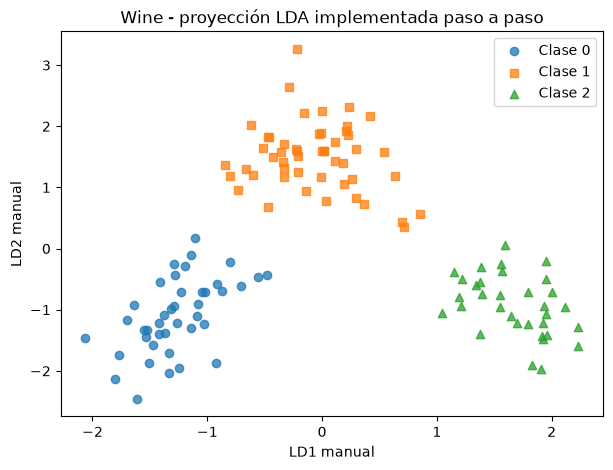

In [11]:
X_train_lda_manual = X_train_std @ W
X_test_lda_manual = X_test_std @ W

plt.figure(figsize=(7, 5))
markers = ['o', 's', '^']
for idx, label in enumerate(classes):
    plt.scatter(
        X_train_lda_manual[y_train == label, 0],
        X_train_lda_manual[y_train == label, 1],
        marker=markers[idx],
        alpha=0.75,
        label=f'Clase {label}',
    )
plt.xlabel('LD1 manual')
plt.ylabel('LD2 manual')
plt.title('Wine - proyección LDA implementada paso a paso')
plt.legend()
plt.show()

**Preguntas de análisis**

1. ¿Qué dimensión tiene $W$? ¿Por qué?

    W tiene dimensión 13x2, donde 13 son las filas y 2 las columnas. Esto es asi porque el espacio original tiene 13 variables y el espacio discriminante tiene dimensión 2 (autovalores).
2. ¿Por qué aparecen solamente dos autovalores importantes aunque el dataset tenga 13 variables?¿cuántas dimensiones tiene el espacio discriminante?
   
    Porque la cantidad máxima de autovalores esta limitada por min(n° caracteristicas, n° clases -1). Entonces, con 3 clases el espacio discriminante tiene dimensión 2.
3. ¿Qué significa geométricamente que las clases se separen mejor después de la proyección?

    Significa que la media esta más alejadas entre sí en relación con la dispersión de la muestra dentro de cada clase.


#### 6. LDA con scikit-learn como transformación supervisada

Utilice `LinearDiscriminantAnalysis(n_components=2)` y compare la representación obtenida con la implementación manual.

In [12]:
linear_discriminant = LinearDiscriminantAnalysis(n_components=2)
X_train_lda = linear_discriminant.fit_transform(X_train_std, y_train)

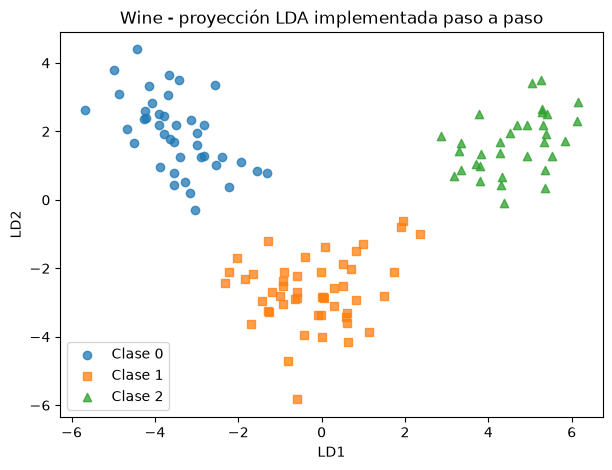

In [13]:
plt.figure(figsize=(7, 5))
markers = ['o', 's', '^']
for idx, label in enumerate(classes):
    plt.scatter(
        X_train_lda[y_train == label, 0],
        X_train_lda[y_train == label, 1],
        marker=markers[idx],
        alpha=0.75,
        label=f'Clase {label}',
    )
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.title('Wine - proyección LDA implementada paso a paso')
plt.legend()
plt.show()

In [14]:
linear_discriminant.explained_variance_ratio_

array([0.6669, 0.3331])

**Investigue:**

1. ¿La proyección de scikit-learn debe ser idéntica punto por punto a la implementación manual?

    No, debido a que los valores pueden diferir en el signo de un eje discriminante haciendo que los valores esten invertidos sin que eso implique un error.

2. ¿Qué significan los valores de `explained_variance_ratio_` del LDA de scikit-learn?

    Indica qué proporción de la varianza explica cada uno de los componenetes. Si no se fija `n_components`, se calcula todos los componentes posibles y la suma de los valores tiene que ser igual a 1.

3. ¿Por qué el signo de un eje discriminante puede aparecer invertido sin que exista un error?
    
    Porque los autovectores no tienen un signo definido, entonces si p es autovector, −p también lo es y representa la misma dirección. Por eso, diferentes implementaciones pueden invertir este signo sin que afecte la separación entre clases.
    

#### 7. LDA como clasificador

Hasta aquí LDA se utilizó como transformación. Ahora úselo directamente como clasificador y evalúe su desempeño sobre el conjunto de prueba reservado. Calcule también la matriz de confusión.

Exactitud LDA: 0.9814814814814815


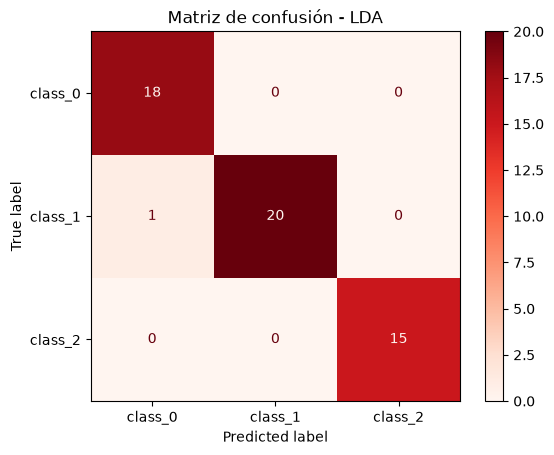

In [15]:
lda_clasificador = LinearDiscriminantAnalysis()
lda_clasificador.fit(X_train_std, y_train)

y_pred_lda = lda_clasificador.predict(X_test_std)

print('Exactitud LDA:', accuracy_score(y_test, y_pred_lda))

#Matriz de confusión
matriz_confusion = confusion_matrix(y_test, y_pred_lda)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion, display_labels=class_names)
disp.plot(cmap="Reds")
plt.title("Matriz de confusión - LDA")
plt.show()

<!-- **Preguntas de análisis**

1. ¿Cuántas muestras fueron clasificadas incorrectamente?
    
    Observando la matriz de confusión, una sola muestra fue clasificada incorrectamente, ya que esta pertenecía a la clase 2 y se predijo como clase 1.

2. ¿Qué diferencia conceptual existe entre usar LDA con `transform()` y usarlo con `predict()`?

    La diferencia entre usar LDA con `transform()` o con `predict()`, es que `transform()` solo proyecta las muestras al espacio discriminante de menor dimensión, mientras que `predict()` utiliza la proyección para saber a qué clase pertenece cada muestra según la regla de decisión de LDA.
    
3. ¿La frontera de decisión de LDA es lineal o no lineal?

    La frontera de decisión es lineal, haciendo que esta sean hiperplanos -->

#### 8. Validación cruzada:

Una única división entrenamiento/prueba puede producir un resultado dependiente de qué muestras quedaron en cada subconjunto. La **validación cruzada de $k$ particiones** repite el proceso $k$ veces: cada partición actúa una vez como validación y las restantes como entrenamiento.

En esta sección se utilizarán 5 particiones. El conjunto de prueba reservado anteriormente **no participa** de esta validación cruzada.

**Consigna.**

Calcule los cinco accuracies de validación cruzada de LDA sobre `X_train, y_train` usando `cross_val_score` de scikit-learn y reporte media y desviación estándar.

In [16]:
pipeline = Pipeline(
    [("scaler", StandardScaler()),
     ("lda", LinearDiscriminantAnalysis())
    ])

validacion_cruzada = cross_val_score(pipeline, X_train, y_train, cv=5)

print("Accuracies:", validacion_cruzada)
print("Media:", validacion_cruzada.mean())
print("Desvío estándar:", validacion_cruzada.std())

Accuracies: [0.96 0.96 1.   1.   1.  ]
Media: 0.984
Desvío estándar: 0.019595917942265444


**Preguntas de análisis**

1. ¿Por qué aparecen cinco valores de accuracy?

    Hay cinco valores de accuracy porque se dividio en 5 particiones el conjunto de entrenamiento.

2. ¿Qué representa la media de esos valores?

    La media de esos valores representa el rendimiento general del modelo más confiable, ya que promedia los indices de desempeño de cada uno de los subconjuntos.

3. ¿Qué información aporta la desviación estándar?

    La desviación estándar indica comó varió el desempeño del modelo en las distintas particiones. Por lo tanto, si el desvío es bajo el modelo generaliza de forma consistente y si es alto indica que el rendimiento depende fuertemente de los datos de cada partición. En este caso vemos que el desvío estándar es muy bajo (0.02), entonces generaliza y no se ve afectado por las muestra que esten en cada partición.

4. ¿Validación cruzada y búsqueda de hiperparámetros son lo mismo?

   No. La validación cruzada sirve para estimar qué tan bien generaliza un modelo, mientras que la búsqueda de hiperparámetros sirve para elegir la mejor configuración de un modelo, estos se fijan antes del entrenamiento, y la validación cruzada se usa dentro de esa búsqueda para comparar el desempeño de las distintas combinaciones.

#### 9. Efecto del escalado en LDA
Compare mediante validación cruzada LDA con y sin `StandardScaler`.

In [17]:
lda_sin_escalado = LinearDiscriminantAnalysis()

val_cruzada_sin_escalado = cross_val_score(lda_sin_escalado, X_train, y_train, cv=5)

print("Accuracies sin escalado:", val_cruzada_sin_escalado, "media: ", val_cruzada_sin_escalado.mean(), "desvío estándar: ", val_cruzada_sin_escalado.std())
print("Accuracies con escalado:", validacion_cruzada, "media: ", validacion_cruzada.mean(), "desvío estándar: ", validacion_cruzada.std())

Accuracies sin escalado: [0.96 0.96 1.   1.   1.  ] media:  0.984 desvío estándar:  0.019595917942265444
Accuracies con escalado: [0.96 0.96 1.   1.   1.  ] media:  0.984 desvío estándar:  0.019595917942265444


Podemos concluir que no hay ninguna diferencia entre ambos casos, ya que LDA no es un método sensible a la escala de las variables. Esto se debe a que este algoritmo calcula las fronteras de decisión a partir de las matrices de covarianza de los datos, capturando la estructura relativa entre las variables esté o no aplicado el escalado.

## Parte B. Máquinas de Soporte Vectorial (SVM)

Una SVM lineal busca un hiperplano de separación:

$$
\mathbf{w}^T\mathbf{x}+b=0
$$

que separe las clases maximizando el **margen**. Los puntos más próximos a la frontera son los **vectores de soporte** y determinan la solución.

![Margen y vectores de soporte](attachment:SVM_1.png)

#### 10. Margen blando y parámetro $C$

Cuando los datos contienen ruido, solapamiento e instancias atípicas, exigir separación perfecta puede producir una frontera poco generalizable. La SVM de margen blando introduce variables de holgura $\xi_i$ y resuelve conceptualmente un compromiso del tipo:

$$
\min_{\mathbf{w},b,\xi}\; \frac{1}{2}\|\mathbf{w}\|^2 + C\sum_i \xi_i.
$$

El hiperparámetro $C$ controla cuánto se penalizan las violaciones del margen:

- **$C$ grande:** penaliza fuertemente los errores; la frontera intenta ajustarse más a las muestras de entrenamiento;
- **$C$ pequeño:** tolera más violaciones y favorece un margen más amplio.

![Efecto conceptual del parámetro C](attachment:SVM_2.png)

> **Escalado en SVM.** SVM es sensible a la escala de los atributos porque tanto el margen como, en kernels como RBF, las distancias entre muestras dependen de la geometría del espacio. Por eso se utilizará `StandardScaler` dentro de un `Pipeline`.

#### 11. Dataset 1: efecto de $C$ y de una observación atípica

El primer dataset es bidimensional y aproximadamente linealmente separable, pero contiene una observación atípica.

**Consigna.**

Entrene SVM lineales con $C\in\{0.01,1,100\}$ y analice cómo cambia la frontera, el número de vectores de soporte y el ajuste al dato atípico.

Use la función `plot_decision_boundary` provista al inicio de la notebook

Dimensiones: (51, 2)
Clases: [0 1]


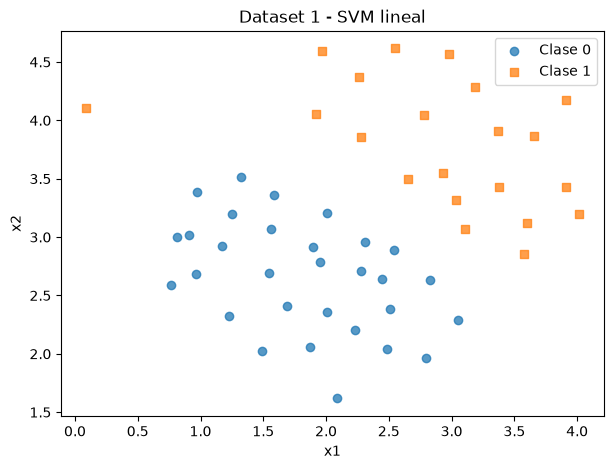

In [18]:
mat1 = sio.loadmat(DATA_DIR / 'data1.mat')
X_svm1 = mat1['X']
y_svm1 = mat1['y'].ravel()

print('Dimensiones:', X_svm1.shape)
print('Clases:', np.unique(y_svm1))
plot_labeled_points(X_svm1, y_svm1, 'Dataset 1 - SVM lineal')

Número de vectores de soporte para C=0.01: 42


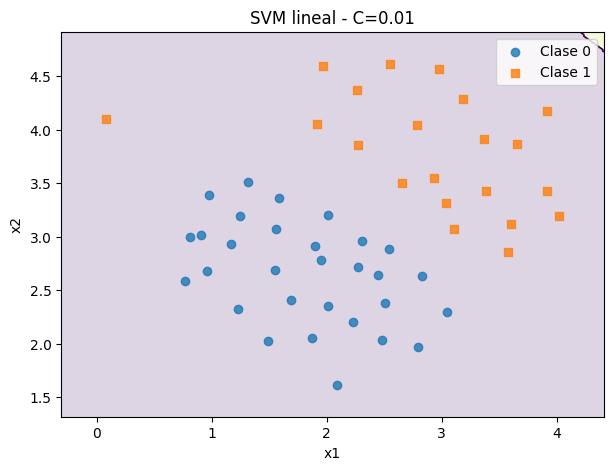

Número de vectores de soporte para C=1: 12


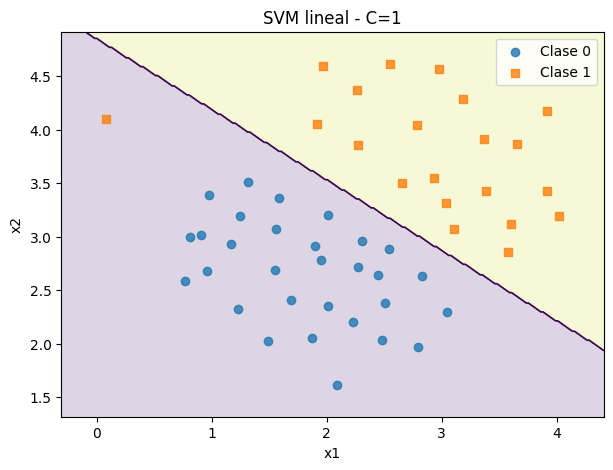

Número de vectores de soporte para C=100: 3


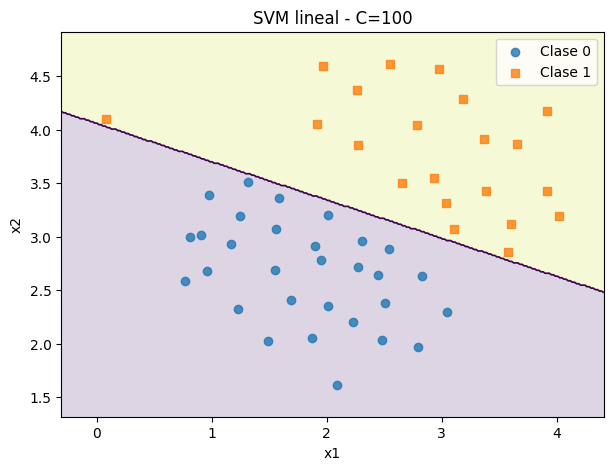

In [31]:
valores_C = [0.01, 1, 100]

for C in valores_C:
    svm_clasificador = SVC(kernel='linear', C=C)
    svm_clasificador.fit(X_svm1, y_svm1)

    numero_soporte = len(svm_clasificador.support_)
    print(f'Número de vectores de soporte para C={C}: {numero_soporte}')

    
    plot_decision_boundary(svm_clasificador, X_svm1, y_svm1, f'SVM lineal - C={C}') 

Análisis:
A medida que aumenta $C$, el número de vectores de soporte disminuye, siendo 42 para un C=0.01, 12 (C=1) y 3 (C=100). Con esto podemos ver que:

- **C=0.01**:

    La frontera de decisión casi no aparece en el rango graficado, lo que indica que el margen es extremadamente ancho y la recta de separación queda muy alejada de los datos. Además, el dato atípico queda del lado equivocado, pero al modelo no le importa, ya que el costo de ese error es mínimo en comparación al beneficio de mantener un margen tan amplio.

- **C=1**:
    La frontera se acerca más a los datos y el margen se hace más angosto que con C=0.01. El número de vectores de soporte baja a 12, lo que indica que el modelo ya no depende  de "casi todos" los puntos para definir la frontera, sino de un subconjunto más chico cercano al límite entre clases. El outlier sigue sin forzar demasiado la frontera, es un punto intermedio entre tolerar el error y ajustarse a él.

- **C=100**:

    El margen se vuelve muy angosto y la frontera se ajusta fuertemente a los datos de entrenamiento, incluyendo el intento de clasificar correctamente al outlier. Solo quedan 3 vectores de soporte, es decir, el modelo usa muy pocos puntos (los más cercanos a la frontera) para definirla, lo cual es una señal de sobreajuste: el modelo prioriza no equivocarse en el outlier aunque eso signifique un margen más frágil frente a datos nuevos.


**Preguntas de análisis**

1. ¿Qué ocurre con el margen cuando $C$ disminuye?

    Cuando $C$ disminuye, el modelo prioriza maximizar la separación entre clases por sobre clasificar correctamente cada punto. Por lo tanto, se observa un margen más blando, es decir, que tolera más errores de clasificación y violaciones de margen (subajuste).

2. ¿Qué ocurre con el ajuste al outlier cuando $C$ aumenta?

    Cuando $C$ aumenta, se observa que el modelo se ajusta más al outlier, buscando clasificarlo correctamente aunque esto signifique sacrificar el margen respecto de los demás puntos.

3. ¿Qué riesgo aparece con un $C$ excesivamente grande?

    Cuando $C$ es excesivamente grande, se corre el riesgo de sobreajuste, ya que el modelo se vuelve muy sensible al ruido de los datos, generando una frontera demasiado ajustada a casos específicos que no logra generalizar bien.

4. ¿Por qué no debería elegirse $C$ solamente observando el accuracy de entrenamiento?

    Porque un $C$ muy grande puede lograr un accuracy de entrenamiento muy alto debido a que ajusta la frontera a cada punto individual, pero eso no refleja qué generalice bien el modelo a datos nuevos. Es por eso que para elegir un $C$ adecuado hay que evaluar el desempeño en datos no vistos durante el entrenamiento.

#### 12. Dataset 2: SVM con kernel RBF y efecto de $\gamma$

Cuando las clases no son separables mediante un hiperplano en el espacio original, una SVM puede utilizar un **kernel**. El kernel RBF o Gaussiano se define como:

$$
K(\mathbf{x},\mathbf{z})=\exp\left(-\gamma\|\mathbf{x}-\mathbf{z}\|^2\right).
$$

El parámetro $\gamma$ controla el alcance de influencia de cada muestra:

- $\gamma$ pequeño: influencia más amplia y frontera más suave;
- $\gamma$ grande: influencia más local y frontera potencialmente más compleja.

**Consigna.**

Mantenga $C=1$ y compare $\gamma\in\{0.01,1,100\}$.

Use la función `plot_decision_boundary` provista al inicio de la notebook

Dimensiones: (863, 2)
Cantidad por clase: [383 480]


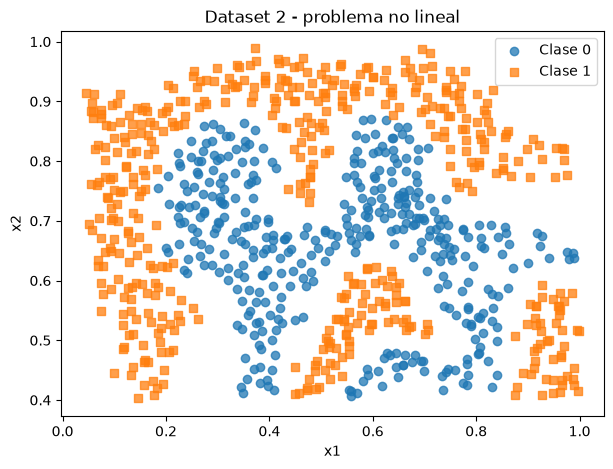

In [19]:
mat2 = sio.loadmat(DATA_DIR / 'data2.mat')
X_svm2 = mat2['X']
y_svm2 = mat2['y'].ravel()

print('Dimensiones:', X_svm2.shape)
print('Cantidad por clase:', np.bincount(y_svm2.astype(int)))
plot_labeled_points(X_svm2, y_svm2, 'Dataset 2 - problema no lineal')

gamma=0.1 --> accuracy train: 0.8215527230590962, vectores de soporte: 498


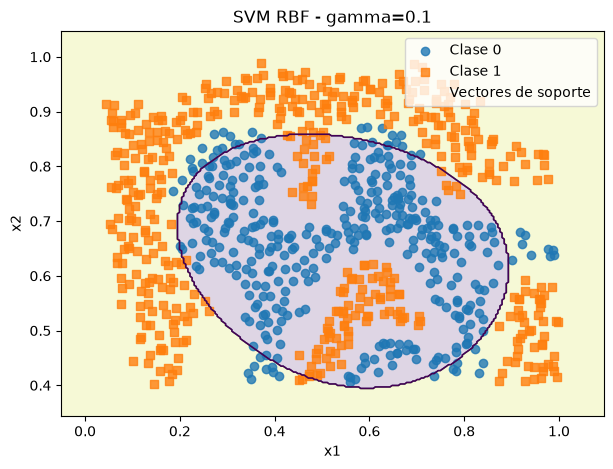

gamma=1 --> accuracy train: 0.9432213209733488, vectores de soporte: 294


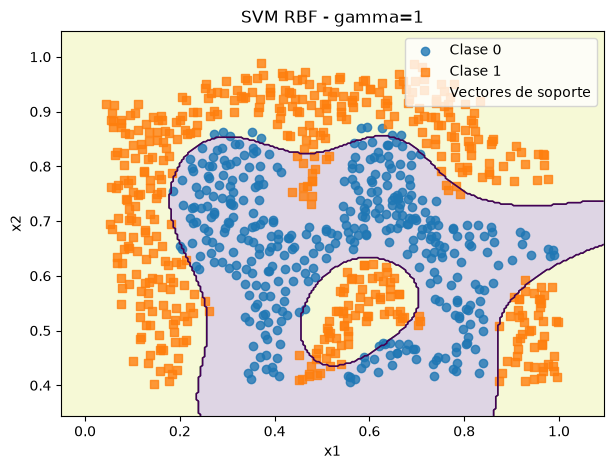

gamma=100 --> accuracy train: 1.0, vectores de soporte: 713


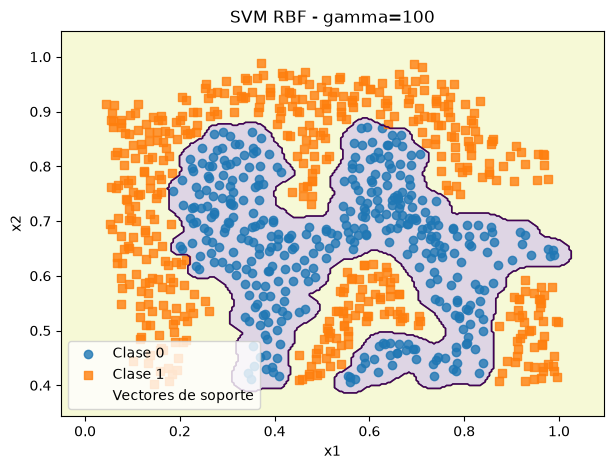

In [ ]:
gamma =[0.1, 1, 100]

for g in gamma:
    #pipeline: primero se escala y despues se entrena el clasificador SVM con kernel RBF
    svm_rbf = Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(kernel='rbf', C=1, gamma=g))
    ])
    svm_rbf.fit(X_svm2, y_svm2)

    accuracy_train = svm_rbf.score(X_svm2, y_svm2)
    numero_soporte = len(svm_rbf.named_steps['svc'].support_)
    print(f'gamma={g} --> accuracy train: {accuracy_train}, vectores de soporte: {numero_soporte}')

    plot_decision_boundary(svm_rbf, X_svm2, y_svm2, f'SVM RBF - gamma= {g}')

**Preguntas de análisis**

1. ¿Qué comportamiento se observa con un $\gamma$ demasiado pequeño?

    Con un $\gamma$ demasiado pequeño se observa un **subajuste**, donde el Kernel no logra captar bien la forma real de los datos 
2. ¿Qué comportamiento se observa con un $\gamma$ demasiado grande?

    Con un $\gamma$ demasiado grande se observa lo opuesto, podemos ver una frontera muy flexible que se adapta a cada grupo de puntos y un accuracy de train perfecto (1.00), obteniendo así un **sobreajuste** del modelo 
3. ¿La configuración que obtiene el mayor accuracy de entrenamiento puede considerarse automáticamente la mejor? Justifique.

    No, la configuración que obtiene el mayor accuracy de entrenamiento no necesariamente se debe considerar automáticamente la mejor, esto se demuestra en el ejercicio anterior, debido a que con un $\gamma$=100 obtuvimos un accuracy perfecto (1.00), sin embargo también obtuvimos un modelo que se ajusta demasiado a los detalles específicos del conjunto de entrenamiento

## Parte C. Selección de hiperparámetros y evaluación final

#### 13. Entrenamiento, validación y prueba

Cuando se entrenan varios modelos o se prueban diferentes hiperparámetros, el conjunto de prueba debe mantenerse completamente separado hasta el final.

Se distinguen tres funciones para los datos:

- **Train:** ajustar los parámetros del modelo.
- **Validation:** comparar configuraciones e hiperparámetros.
- **Test:** realizar una evaluación final del procedimiento elegido.

Si los datos disponibles no permiten reservar una gran fracción para validación, puede utilizarse **validación cruzada** sobre los datos de desarrollo. Aun utilizando validación cruzada, conviene conservar un conjunto de prueba independiente para la evaluación final.

En esta sección se utilizará `data3_train_val_test.mat`, preparado con conjuntos explícitos de entrenamiento, validación y prueba.

Train: (211, 2) [105 106]
Validation: (100, 2) [56 44]
Test: (100, 2) [57 43]


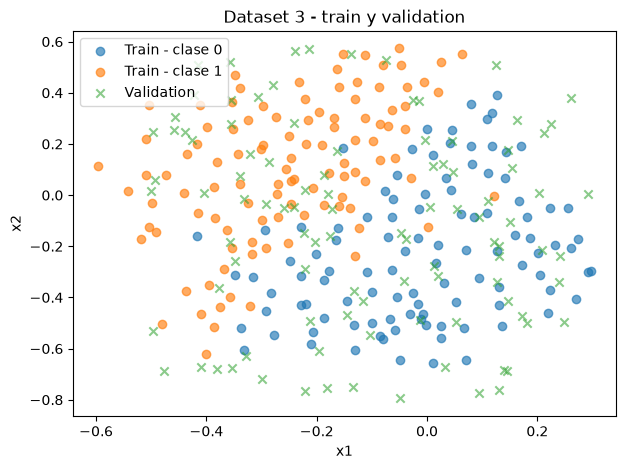

In [22]:
mat3 = sio.loadmat(DATA_DIR / 'data3_train_val_test.mat')

X_train_3 = mat3['X_train']
y_train_3 = mat3['y_train'].ravel()
X_val_3 = mat3['X_val']
y_val_3 = mat3['y_val'].ravel()
X_test_3 = mat3['X_test']
y_test_3 = mat3['y_test'].ravel()

print('Train:', X_train_3.shape, np.bincount(y_train_3.astype(int)))
print('Validation:', X_val_3.shape, np.bincount(y_val_3.astype(int)))
print('Test:', X_test_3.shape, np.bincount(y_test_3.astype(int)))

plt.figure(figsize=(7, 5))
for label in np.unique(y_train_3):
    plt.scatter(
        X_train_3[y_train_3 == label, 0],
        X_train_3[y_train_3 == label, 1],
        alpha=0.65,
        label=f'Train - clase {label}',
    )
plt.scatter(X_val_3[:, 0], X_val_3[:, 1], marker='x', alpha=0.55, label='Validation')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Dataset 3 - train y validation')
plt.legend()
plt.show()

#### 14. Selección manual con un único conjunto de validación

Primero se imitará un procedimiento clásico de selección hold-out:

1. entrenar cada combinación de $C$ y $\gamma$ usando **solo train**;
2. medir su accuracy en **validation**;
3. ordenar las configuraciones de mayor a menor desempeño.

Use:

```python
valores_C = [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]
valores_gamma = [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 300]
```

**Importante:** el escalado debe estar dentro de un `Pipeline`, de modo que cada modelo ajuste el escalador solo con sus datos de entrenamiento.

In [24]:
valores_C = [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]
valores_gamma = [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 300]

In [25]:
resultados_holdout = []

#recorremos todas las combinaciones de C y gamma
for C in valores_C:
    for gamma in valores_gamma:
        #pipeline: primero se escala (el scaler se ajusta con fit y solo con X_train_3) y despues se entrena el clasificador SVM con kernel RBF
        modelo = Pipeline([
            ('scaler', StandardScaler()),
            ('svc', SVC(kernel='rbf', C=C, gamma=gamma))
        ])
        modelo.fit(X_train_3, y_train_3)

        #evaluamos en validacion (datos que el modelo no vio)
        accuracy_val = modelo.score(X_val_3, y_val_3)

        resultados_holdout.append({"C": C, "gamma": gamma, "accuracy_val": accuracy_val}) 

#pasamos a un DataFrame para poder analizarlo mejor
df_holdout = pd.DataFrame(resultados_holdout)
df_holdout.sort_values(by='accuracy_val', ascending=False, inplace=True) #ordenamos de mayor a menor accuracy

print(df_holdout.head(10))

        C  gamma  accuracy_val
22    0.1    1.0          0.99
75  100.0    0.3          0.99
67   30.0    1.0          0.99
32    0.3    3.0          0.99
50    3.0    3.0          0.98
39    1.0    0.3          0.98
40    1.0    1.0          0.98
49    3.0    1.0          0.98
48    3.0    0.3          0.98
23    0.1    3.0          0.98


**Preguntas de análisis**

1. ¿Hay una única combinación ganadora o aparecen empates?
2. Si varias configuraciones obtienen el mismo accuracy de validación, ¿qué problema aparece al elegir una?
3. ¿Podemos utilizar el conjunto de test para desempatar?
4. ¿Qué limitación tiene basar toda la decisión en un único conjunto de validación de 100 muestras?

#### 15. Validación cruzada para seleccionar hiperparámetros

Ahora se combinarán `train` y `validation` en un conjunto de **train_val**. El conjunto de test seguirá completamente aislado.

Para cada combinación de $C$ y $\gamma$ se calculará el accuracy medio de una validación cruzada de 5 particiones usando `cross_val_score`.

Esto permite que diferentes subconjuntos de `train_val` actúen como validación, reduciendo la dependencia respecto de una única partición.

In [27]:
X_train_val_3 = np.vstack([X_train_3, X_val_3])
y_train_val_3 = np.concatenate([y_train_3, y_val_3])

print('Train+Val:', X_train_val_3.shape)
print('Test reservado:', X_test_3.shape)

Train+Val: (311, 2)
Test reservado: (100, 2)


In [28]:
resultados_cv=[]

for C in valores_C:
    for gamma in valores_gamma:
        #pipeline: primero se escala (el scaler se ajusta con fit y solo con X_train_val_3) y despues se entrena el clasificador SVM con kernel RBF
        modelo = Pipeline([
            ('scaler', StandardScaler()),
            ('svc', SVC(kernel='rbf', C=C, gamma=gamma))
        ])
        #validacion cruzada se encarga de dividir train_val en 5 folds, ajustnado el pipeline dentro de cada fold por separado 
        scores = cross_val_score(modelo, X_train_val_3, y_train_val_3, cv=5)

        resultados_cv.append({"C": C, "gamma": gamma, "cv_mean": scores.mean(), "cv_std": scores.std()})

#pasamos a un DataFrame para poder analizarlo mejor
df_cv = pd.DataFrame(resultados_cv)
df_cv.sort_values(by='cv_mean', ascending=False, inplace=True) #ordenamos de mayor a menor accuracy

print(df_cv.head(10))

        C  gamma   cv_mean    cv_std
75  100.0    0.3  0.951971  0.036153
32    0.3    3.0  0.948746  0.033806
40    1.0    1.0  0.948746  0.035311
41    1.0    3.0  0.945520  0.032587
42    1.0   10.0  0.945520  0.032587
67   30.0    1.0  0.942345  0.038233
49    3.0    1.0  0.942345  0.038233
50    3.0    3.0  0.942345  0.040864
74  100.0    0.1  0.942294  0.029259
57   10.0    0.3  0.942294  0.029259


**Preguntas de análisis**

1. ¿La mejor combinación obtenida con validación cruzada coincide necesariamente con alguna de las mejores del hold-out validation?
2. ¿Por qué el mejor accuracy medio de CV puede ser menor que el obtenido con hold-out?
3. ¿Qué información adicional aporta `cv_std`?

#### 16. Automatización con `GridSearchCV`

`GridSearchCV` automatiza el procedimiento anterior:

- genera todas las combinaciones del diccionario `param_grid`
- evalúa cada combinación mediante validación cruzada
- selecciona la configuración con mejor score medio
- vuelve a ajustar el mejor pipeline utilizando todos los datos del conjunto train_val cuando `refit=True`.

**Consigna.** Repita la búsqueda anterior con `GridSearchCV` y compare los resultados con la búsqueda manual.

**¿Llega al mismo resultado?**

In [29]:
param_grid = {
    'svc__C': valores_C,
    'svc__gamma': valores_gamma,
}

In [30]:
#pipeline: primero se escala y despues se entrena el clasificador SVM con kernel RBF
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf'))
])

grid_search = GridSearchCV(
    pipeline_svm, 
    param_grid, 
    cv=5, #misma cant de particiones que antes
    refit=True #al terminar reentrena automaticamente con todo train_val usando la mejor combinacion 
) 

grid_search.fit(X_train_val_3, y_train_val_3)

print("Mejor combincacion (GridSearchCV):", grid_search.best_params_)
print("Mejor score medio de CV:", grid_search.best_score_)

Mejor combincacion (GridSearchCV): {'svc__C': 100, 'svc__gamma': 0.3}
Mejor score medio de CV: 0.9519713261648747


**Comaparación entre GridSearchCV y la forma manual:**



#### 17. Evaluación final sobre test

Hasta este punto, el conjunto `X_test_3, y_test_3` no se utilizó para elegir hiperparámetros. Recién ahora se empleará para estimar el desempeño final del mejor modelo seleccionado.

**Consigna.** Evalúe `grid_search.best_estimator_` sobre test, muestre la matriz de confusión y grafique la frontera de decisión.

Use la función `plot_decision_boundary` provista al inicio de la notebook

Accuracy en test: 0.93


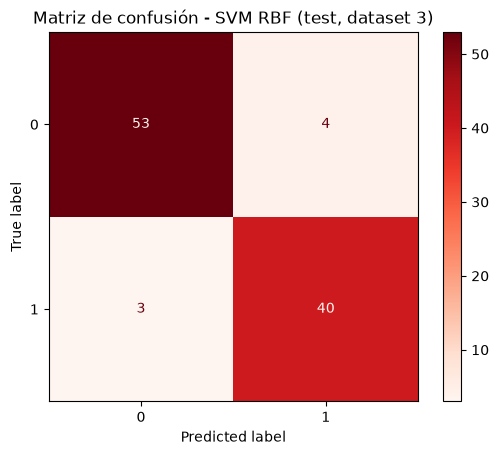

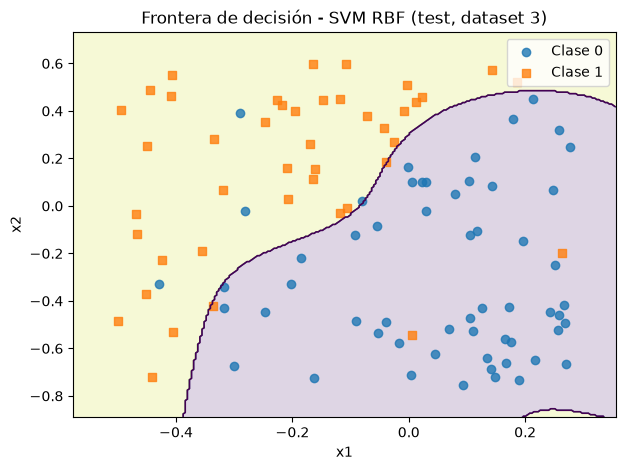

In [34]:
mejor_modelo = grid_search.best_estimator_

y_pred_test = mejor_modelo.predict(X_test_3)
accuracy_test = accuracy_score(y_test_3, y_pred_test)
print("Accuracy en test:", accuracy_test)

#matriz de confusión
matriz_confusion_3= confusion_matrix(y_test_3, y_pred_test)
disp= ConfusionMatrixDisplay(confusion_matrix=matriz_confusion_3)
disp.plot(cmap="Reds")
plt.title("Matriz de confusión - SVM RBF (test, dataset 3)")
plt.show()

#frontera de decisión del modelo final, mostrando los datos de test
plot_decision_boundary(mejor_modelo, X_test_3, y_test_3, 'Frontera de decisión - SVM RBF (test, dataset 3)', show_support=False)

**Preguntas de análisis**

1. ¿Por qué el test debe utilizarse recién después de finalizar la selección de hiperparámetros?
2. ¿Qué ocurriría si, al ver el resultado de test, modificáramos nuevamente $C$ o $\gamma$ para mejorarlo?

## Parte D. Comparar LDA y SVM sobre el mismo problema

Volvamos al Wine dataset. Utilice la misma partición que usó al inicio (train + test).

El objetivo es comparar modelos utilizando **la misma estrategia de evaluación**, evitando comparar scores obtenidos bajo procedimientos distintos.

Se considerarán tres clasificadores:

- LDA
- SVM lineal
- SVM con kernel RBF.

LDA se evaluará por validación cruzada. Para las SVM, los hiperparámetros se seleccionarán con `GridSearchCV` sobre el mismo conjunto de entrenamiento. El conjunto de prueba de Wine seguirá reservado hasta seleccionar el mejor candidato según CV.

#### 18. Comparación de clasificadores

**Consigna.** Sobre `X_train, y_train`:

1. estime el desempeño de LDA con `cross_val_score(cv=5)`;
2. seleccione $C$ para SVM lineal mediante `GridSearchCV`;
3. seleccione $C$ y $\gamma$ para SVM RBF mediante `GridSearchCV`;
4. compare los mejores scores medios de validación cruzada.

In [35]:
#1. LDA con validacion cruzada
pipeline_lda = Pipeline([
    ('scaler', StandardScaler()),
    ('lda', LinearDiscriminantAnalysis())
])

scores_lda = cross_val_score(pipeline_lda, X_train, y_train, cv=5)
print("LDA - CV mean:", scores_lda.mean(), "| CV std:", scores_lda.std())

#2. SVM lineal - gridsearchcv solo sobre c
pipeline_svm_lineal=Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='linear'))
])

param_grid_lineal = {'svc__C': [0.01, 0.1, 1, 10, 100]}
grid_lineal = GridSearchCV(pipeline_svm_lineal, param_grid_lineal, cv=5)
grid_lineal.fit(X_train, y_train)
print("SVM lineal - mejor C:", grid_lineal.best_params_, "| CV mean:", grid_lineal.best_score_)

#3. SVM RBF - gridsearchcv sobre C y gamma
pipeline_svm_rbf=Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf'))
])

param_grid_rbf = {'svc__C': [0.01, 0.1, 1, 10, 100], 'svc__gamma': [0.001, 0.01, 0.1, 1, 10]}
grid_rbf = GridSearchCV(pipeline_svm_rbf, param_grid_rbf, cv=5)
grid_rbf.fit(X_train, y_train)
print("SVM RBF - mejores parámetros:", grid_rbf.best_params_, "| CV mean:", grid_rbf.best_score_)

#4. comparación de los modelos 
print("\nResumen:")
print(f"LDA: {scores_lda.mean():.4f}")
print(f"SVM lineal: {grid_lineal.best_score_:.4f}")
print(f"SVM RBF: {grid_rbf.best_score_:.4f}")

LDA - CV mean: 0.984 | CV std: 0.019595917942265444
SVM lineal - mejor C: {'svc__C': 0.1} | CV mean: 0.9836666666666666
SVM RBF - mejores parámetros: {'svc__C': 1, 'svc__gamma': 0.1} | CV mean: 0.992

Resumen:
LDA: 0.9840
SVM lineal: 0.9837
SVM RBF: 0.9920


**¿Qué modelo obtiene el mejor score medio de CV en esta ejecución?**

#### 19. Evaluación del modelo seleccionado en Wine

Seleccione el candidato con mejor score de validación cruzada y evalúelo **una sola vez** sobre el test reservado al comienzo.

**Comente el resultado**


Accuracy en test con el mejor modelo (SVM RBF): 0.9815


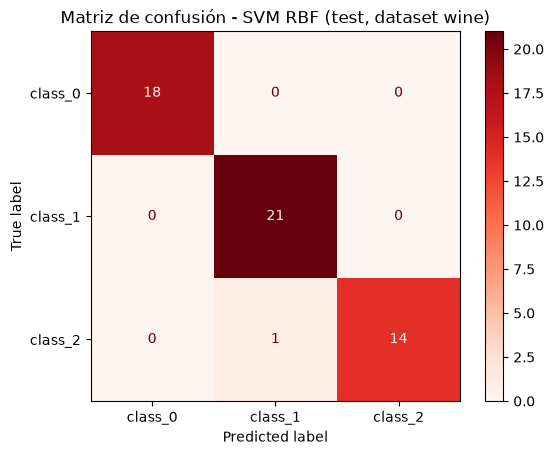

In [36]:
modelo_final=grid_rbf.best_estimator_

y_pred_wine=modelo_final.predict(X_test)
accuracy_wine_test = accuracy_score(y_test, y_pred_wine)
print(f"\nAccuracy en test con el mejor modelo (SVM RBF): {accuracy_wine_test:.4f}")

matriz_wine= confusion_matrix(y_test, y_pred_wine)
disp= ConfusionMatrixDisplay(confusion_matrix=matriz_wine, display_labels=class_names)
disp.plot(cmap="Reds")
plt.title("Matriz de confusión - SVM RBF (test, dataset wine)")
plt.show()

#### 20. LDA como transformación antes de otro clasificador

LDA también puede colocarse dentro de un `Pipeline` antes de otro clasificador. Esto permite estudiar una secuencia del tipo:

$$
X \rightarrow \text{StandardScaler} \rightarrow \text{LDA} \rightarrow \text{SVM}.
$$

La transformación LDA es **supervisada**, porque utiliza las etiquetas $y$. Por eso, si se evalúa mediante validación cruzada, LDA debe ajustarse **dentro de cada fold**. Ajustar LDA sobre todo el dataset y luego hacer CV sobre la representación transformada produciría fuga de información.

**Consigna**

Evalúe el pipeline `Scaler → LDA(n_components=2) → SVM lineal` con validación cruzada.

Compare con los resultados de los modelos en 19 y comente el resultado

In [37]:
pipeline_lda_svm=Pipeline([
    ('scaler', StandardScaler()),
    ('lda', LinearDiscriminantAnalysis(n_components=2)), 
    ('svc', SVC(kernel='linear'))
])

scores_lda_svm = cross_val_score(pipeline_lda_svm, X_train, y_train, cv=5)
print("Scaler --> LDA --> SVM lineal - CV mean:", scores_lda_svm.mean(), "| CV std:", scores_lda_svm.std())

Scaler --> LDA --> SVM lineal - CV mean: 0.992 | CV std: 0.016000000000000014
